In [466]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [467]:
DATA_PATH = Path("../data/processed/tickets_with_escalation.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns.tolist())
df.head()

(8469, 30)
['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating', 'ticket_text', 'text_length', 'word_count', 'has_urgent_keyword', 'has_payment_keyword', 'has_login_keyword', 'has_error_keyword', 'customer_tier', 'affected_users', 'previous_tickets_count', 'created_hour', 'escalation_probability_true', 'is_escalated']


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,has_urgent_keyword,has_payment_keyword,has_login_keyword,has_error_keyword,customer_tier,affected_users,previous_tickets_count,created_hour,escalation_probability_true,is_escalated
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,0,1,0,1,standard,100,3,0,0.822229,1
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,0,0,0,1,enterprise,10,2,14,0.740507,0
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,0,1,0,0,premium,50,1,15,0.658627,1
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,0,0,1,1,standard,1,7,9,0.517685,1
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,0,0,0,1,free,5,1,19,0.364433,1


In [468]:
required_columns = [
    "customer_tier",
    "ticket_channel",
    "affected_users",
    "previous_tickets_count",
    "created_hour",
    "text_length",
    "word_count",
    "has_urgent_keyword",
    "has_payment_keyword",
    "has_login_keyword",
    "has_error_keyword",
    "is_escalated"
]

missing_columns = [col for col in required_columns if col not in df.columns]

missing_columns

[]

In [469]:
tier_complexity = df["customer_tier"].map({
    "free": 0.5,
    "standard": 1.0,
    "premium": 1.5,
    "enterprise": 2.0
})

channel_complexity = df["ticket_channel"].map({
    "email": 0.5,
    "web": 0.7,
    "chat": 0.9,
    "phone": 1.2
})

affected_users_factor = np.log1p(df["affected_users"]) * 1.2
previous_tickets_factor = np.log1p(df["previous_tickets_count"]) * 1.5

keyword_factor = (
    2.5 * df["has_urgent_keyword"]
    + 2.0 * df["has_error_keyword"]
    + 1.5 * df["has_payment_keyword"]
    + 0.8 * df["has_login_keyword"]
)

escalation_factor = 3.5 * df["is_escalated"]

noise = np.random.normal(loc=0, scale=2.0, size=len(df))

df["resolution_time_hours"] = (
    2.0
    + tier_complexity
    + channel_complexity
    + affected_users_factor
    + previous_tickets_factor
    + keyword_factor
    + escalation_factor
    + noise
)

# Keep resolution time realistic and positive
df["resolution_time_hours"] = df["resolution_time_hours"].clip(lower=0.5)

df["resolution_time_hours"].describe()

count    8469.000000
mean       12.970585
std         3.873088
min         0.500000
25%        10.137441
50%        12.984231
75%        15.753669
max        27.757758
Name: resolution_time_hours, dtype: float64

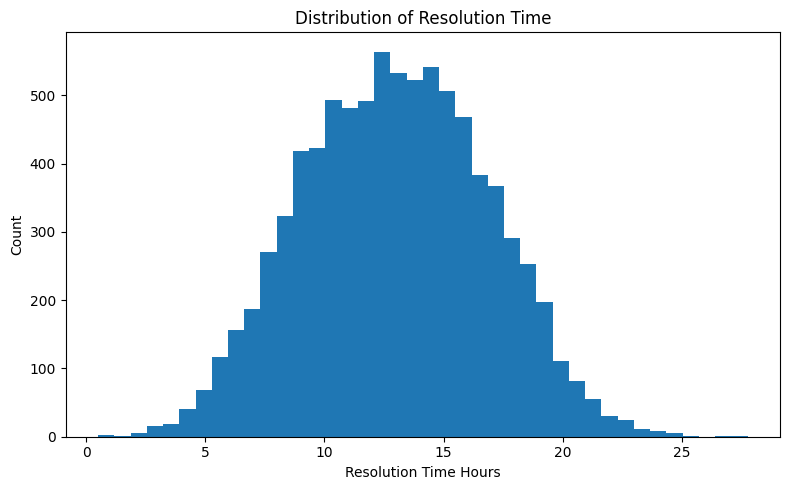

In [470]:
plt.figure(figsize=(8, 5))
plt.hist(df["resolution_time_hours"], bins=40)
plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time Hours")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [471]:
df.groupby("is_escalated")["resolution_time_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
is_escalated,,,,,,,,
0,3321.0,9.920970,2.869974,0.50000,7.976786,9.786339,11.805362,19.669912
1,5148.0,14.937906,3.081386,4.82619,12.769247,14.885115,17.050693,27.757758


In [472]:
features = [
    "customer_tier",
    "ticket_channel",
    "affected_users",
    "previous_tickets_count",
    "created_hour",
    "text_length",
    "word_count",
    "has_urgent_keyword",
    "has_payment_keyword",
    "has_login_keyword",
    "has_error_keyword"
]

target = "resolution_time_hours"

X = df[features]
y = df[target]

X.head()

,customer_tier,ticket_channel,affected_users,previous_tickets_count,created_hour,text_length,word_count,has_urgent_keyword,has_payment_keyword,has_login_keyword,has_error_keyword
0,standard,email,100,3,0,298,45,0,1,0,1
1,enterprise,email,10,2,14,307,46,0,0,0,1
2,premium,email,50,1,15,291,44,0,1,0,0
3,standard,email,1,7,9,277,43,0,0,1,1
4,free,email,5,1,19,343,57,0,0,0,1


In [473]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((6775, 11), (1694, 11))

In [474]:
numeric_features = [
    "affected_users",
    "previous_tickets_count",
    "created_hour",
    "text_length",
    "word_count",
    "has_urgent_keyword",
    "has_payment_keyword",
    "has_login_keyword",
    "has_error_keyword"
]

categorical_features = [
    "customer_tier",
    "ticket_channel"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [475]:
def evaluate_regression_model(model_name, model, X_test, y_test):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"{model_name}")
    print("-" * 50)
    print(f"MAE:  {mae:.3f} hours")
    print(f"RMSE: {rmse:.3f} hours")
    print(f"R²:   {r2:.3f}")
    
    return {
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }, preds

In [476]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_results, linear_preds = evaluate_regression_model(
    "Linear Regression",
    linear_model,
    X_test,
    y_test
)

Linear Regression
--------------------------------------------------
MAE:  2.432 hours
RMSE: 2.954 hours
R²:   0.394


In [477]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_results, ridge_preds = evaluate_regression_model(
    "Ridge Regression",
    ridge_model,
    X_test,
    y_test
)

Ridge Regression
--------------------------------------------------
MAE:  2.432 hours
RMSE: 2.954 hours
R²:   0.394


In [478]:
rf_regressor = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_regressor.fit(X_train, y_train)

rf_results, rf_preds = evaluate_regression_model(
    "Random Forest Regressor",
    rf_regressor,
    X_test,
    y_test
)

Random Forest Regressor
--------------------------------------------------
MAE:  2.199 hours
RMSE: 2.706 hours
R²:   0.492


In [479]:
results_df = pd.DataFrame([
    linear_results,
    ridge_results,
    rf_results
])

results_df

,model,mae,rmse,r2
0,Linear Regression,2.432263,2.954283,0.394475
1,Ridge Regression,2.432273,2.954280,0.394476
2,Random Forest Regressor,2.198756,2.705529,0.492154


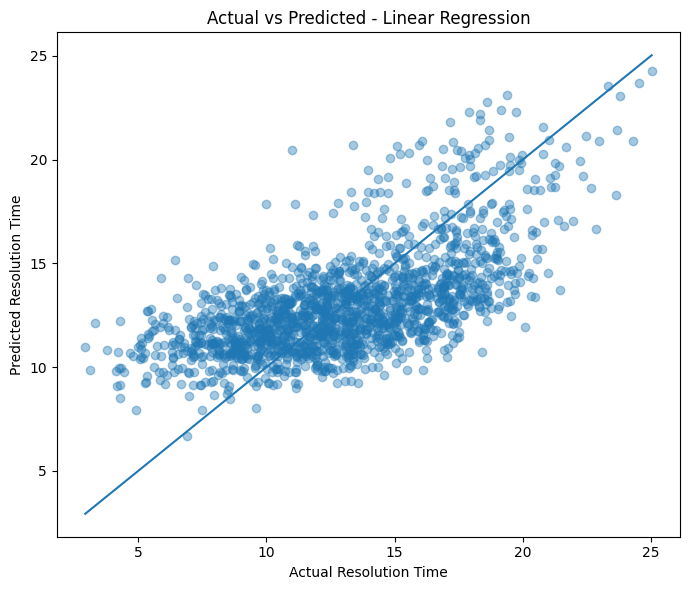

In [480]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, linear_preds, alpha=0.4)
plt.xlabel("Actual Resolution Time")
plt.ylabel("Predicted Resolution Time")
plt.title("Actual vs Predicted - Linear Regression")

min_value = min(y_test.min(), linear_preds.min())
max_value = max(y_test.max(), linear_preds.max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.tight_layout()
plt.show()

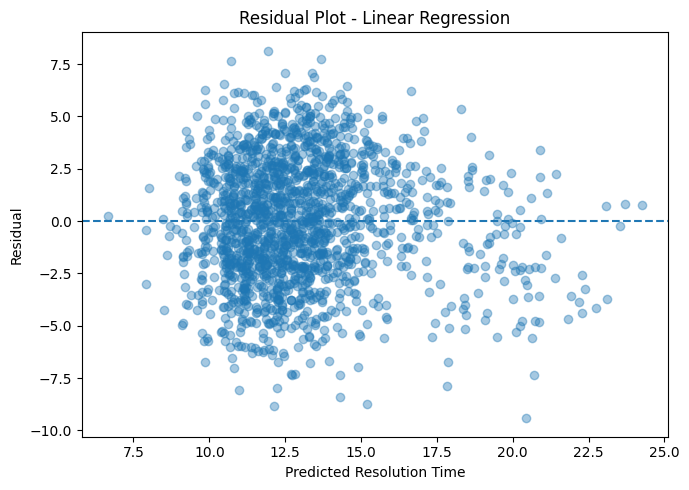

In [481]:
residuals = y_test - linear_preds

plt.figure(figsize=(7, 5))
plt.scatter(linear_preds, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Resolution Time")
plt.ylabel("Residual")
plt.title("Residual Plot - Linear Regression")
plt.tight_layout()
plt.show()

In [482]:
trained_preprocessor = linear_model.named_steps["preprocessor"]
trained_model = linear_model.named_steps["model"]

feature_names = trained_preprocessor.get_feature_names_out()
coefficients = trained_model.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
0,num__affected_users,1.832895
9,cat__customer_tier_enterprise,1.169282
1,num__previous_tickets_count,0.920682
6,num__has_payment_keyword,0.735138
5,num__has_urgent_keyword,0.635143
15,cat__ticket_channel_phone,0.602864
8,num__has_error_keyword,0.451417
11,cat__customer_tier_premium,0.426359
7,num__has_login_keyword,0.253725
13,cat__ticket_channel_chat,0.120813


In [483]:
best_model = linear_model
best_model_name = "linear_regression"

if ridge_results["mae"] < linear_results["mae"]:
    best_model = ridge_model
    best_model_name = "ridge_regression"

if rf_results["mae"] < min(linear_results["mae"], ridge_results["mae"]):
    best_model = rf_regressor
    best_model_name = "random_forest_regressor"

MODEL_PATH = Path("../models/resolution_time_model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODEL_PATH)

print(f"Saved {best_model_name} to {MODEL_PATH}")

Saved random_forest_regressor to ..\models\resolution_time_model.pkl


In [484]:
loaded_model = joblib.load(MODEL_PATH)

sample = X_test.head(1)
loaded_model.predict(sample)

array([12.04444417])

In [485]:
processed_path = Path("../data/processed/tickets_with_escalation_and_resolution.csv")
df.to_csv(processed_path, index=False)

processed_path

WindowsPath('../data/processed/tickets_with_escalation_and_resolution.csv')

In [486]:
trained_preprocessor = linear_model.named_steps["preprocessor"]
trained_model = linear_model.named_steps["model"]

feature_names = trained_preprocessor.get_feature_names_out()
coefficients = trained_model.coef_
intercept = trained_model.intercept_

print("Intercept:", intercept)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

coef_df

Intercept: 13.44271058696648


,feature,coefficient
0,num__affected_users,1.832895
9,cat__customer_tier_enterprise,1.169282
1,num__previous_tickets_count,0.920682
6,num__has_payment_keyword,0.735138
5,num__has_urgent_keyword,0.635143
15,cat__ticket_channel_phone,0.602864
8,num__has_error_keyword,0.451417
11,cat__customer_tier_premium,0.426359
7,num__has_login_keyword,0.253725
13,cat__ticket_channel_chat,0.120813


In [487]:
equation_parts = [f"{intercept:.4f}"]

for feature, coef in zip(feature_names, coefficients):
    equation_parts.append(f"({coef:.4f} * {feature})")

equation = " + ".join(equation_parts)

print("predicted_resolution_time = " + equation)

predicted_resolution_time = 13.4427 + (1.8329 * num__affected_users) + (0.9207 * num__previous_tickets_count) + (0.0425 * num__created_hour) + (-0.0199 * num__text_length) + (-0.0243 * num__word_count) + (0.6351 * num__has_urgent_keyword) + (0.7351 * num__has_payment_keyword) + (0.2537 * num__has_login_keyword) + (0.4514 * num__has_error_keyword) + (1.1693 * cat__customer_tier_enterprise) + (-1.1640 * cat__customer_tier_free) + (0.4264 * cat__customer_tier_premium) + (-0.4316 * cat__customer_tier_standard) + (0.1208 * cat__ticket_channel_chat) + (-0.4447 * cat__ticket_channel_email) + (0.6029 * cat__ticket_channel_phone) + (-0.2790 * cat__ticket_channel_web)
